# Siamese Network - Training & Phase 1 Prediction
1. Load & preprocess data
2. Train siamese model on sampled pairs (fast)
3. Evaluate on validation pairs
4. Predict on task_1.csv groups
5. Demo output with images & titles

In [84]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import os
import pickle
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

pd.options.display.max_columns = None
pd.options.display.max_colwidth = 80

data_folder = "../data/"
images_folder = "../../images/"
pipelines_folder = "../pipelines/"

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Running on MPS")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Running on CUDA")
else:
    device = torch.device("cpu")
    print("Running on CPU")

print(f"Device: {device}")

Running on MPS
Device: mps


## 1. Load & Preprocess Data

In [85]:
# Load raw data
df_train = pd.read_csv(os.path.join(data_folder, 'items_train.csv'))
df_phase1 = pd.read_csv(os.path.join(data_folder, 'items_phase_1.csv'))
df_task_1 = pd.read_csv(os.path.join(data_folder, 'task_1.csv'))

print(f"Train items: {len(df_train)}")
print(f"Phase 1 items: {len(df_phase1)}")
print(f"Task 1 groups: {len(df_task_1)}")

Train items: 928234
Phase 1 items: 199835
Task 1 groups: 15000


In [86]:
# Preprocess using saved pipeline
pipeline = pickle.load(open(os.path.join(pipelines_folder, 'preprocessing_pipeline.pkl'), 'rb'))

X_train = df_train.drop(columns=['label'])
y_train = df_train['label']

df_train_transformed = pipeline.transform(X_train)
df_train_transformed['label'] = y_train.values

df_phase1_transformed = pipeline.transform(df_phase1)

print(f"Train transformed: {len(df_train_transformed)}")
print(df_train_transformed.columns.tolist())

Train transformed: 928234
['brandEditionTagId', 'description', 'title', 'price_eur', 'price_scaled', 'geo', 'departmentIds', 'itemId', 'colorTagIdsString', 'label']


In [87]:
# Load CLIP embeddings (pre-computed)
print("Loading CLIP embeddings...")
clip_embeddings_dict = torch.load("clip_embeddings.pt", map_location='cpu', weights_only=False)
print(f"Loaded {len(clip_embeddings_dict)} image embeddings")

# Check embedding dimension
sample_key = next(iter(clip_embeddings_dict))
print(f"Embedding dim: {clip_embeddings_dict[sample_key].shape}")

Loading CLIP embeddings...
Loaded 928234 image embeddings
Embedding dim: torch.Size([768])
Loaded 928234 image embeddings
Embedding dim: torch.Size([768])


In [88]:
# Load vocabulary
from GlamiDatasetVocabulary import GlamiVocabularyManager
vocab_manager = GlamiVocabularyManager.load_from_dir("vocabularies")
print(f"Geo classes: {len(vocab_manager.geo_dict)}")
print(f"Color classes: {len(vocab_manager.color_dict)}")
print(f"Dept classes: {len(vocab_manager.dept_dict)}")

Geo classes: 13
Color classes: 94
Dept classes: 3


## 1b. Precompute Text Embeddings (CLIP text encoder)\nRun once → saved to `text_embeddings.pt`. Title + description are concatenated and encoded.\nCLIP text encoder produces **512-dim** vectors, same model family as the image embeddings.

In [89]:
from transformers import CLIPTokenizerFast, CLIPTextModelWithProjection

TEXT_EMB_PATH = "text_embeddings.pt"
TEXT_EMB_DIM = 512  # CLIP text projection output

def create_text_embeddings(df_list, save_path, batch_size=512):
    """Encode title+description for every item using CLIP text encoder.
    
    Saves dict {str(item_id): tensor(512)} to save_path.
    """
    model_id = "openai/clip-vit-base-patch32"
    print(f"Loading CLIP text model: {model_id}")
    tokenizer = CLIPTokenizerFast.from_pretrained(model_id)
    text_model = CLIPTextModelWithProjection.from_pretrained(model_id).to(device)
    text_model.eval()

    # Merge all dataframes, keep only needed columns
    all_rows = pd.concat([df[['itemId', 'title', 'description']] for df in df_list], ignore_index=True)
    all_rows = all_rows.drop_duplicates(subset='itemId').reset_index(drop=True)
    all_rows['title'] = all_rows['title'].fillna('')
    all_rows['description'] = all_rows['description'].fillna('')
    all_rows['text'] = (all_rows['title'] + ' ' + all_rows['description']).str.strip()

    embeddings_dict = {}
    item_ids = all_rows['itemId'].astype(str).tolist()
    texts = all_rows['text'].tolist()

    print(f"Encoding {len(texts)} items in batches of {batch_size}...")
    for i in tqdm(range(0, len(texts), batch_size), desc="Text encoding"):
        batch_ids   = item_ids[i:i + batch_size]
        batch_texts = texts[i:i + batch_size]

        inputs = tokenizer(
            batch_texts,
            padding=True, truncation=True, max_length=77,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            outputs = text_model(**inputs)
            # text_embeds is already projected to 512d
            embeds = outputs.text_embeds.cpu()  # [B, 512]

        for j, iid in enumerate(batch_ids):
            embeddings_dict[iid] = embeds[j]

    print(f"Saving {len(embeddings_dict)} text embeddings → {save_path}")
    torch.save(embeddings_dict, save_path)
    print("Done!")
    return embeddings_dict


if os.path.exists(TEXT_EMB_PATH):
    print(f"Loading cached text embeddings from {TEXT_EMB_PATH}...")
    text_embeddings_dict = torch.load(TEXT_EMB_PATH, map_location='cpu', weights_only=False)
    print(f"Loaded {len(text_embeddings_dict)} text embeddings  (dim={TEXT_EMB_DIM})")
else:
    print("Text embeddings not found — computing now (one-time cost)...")
    # Pass BOTH train AND phase1 so phase1 inference also has text embeddings
    text_embeddings_dict = create_text_embeddings(
        [df_train_transformed, df_phase1_transformed],
        save_path=TEXT_EMB_PATH,
        batch_size=512
    )


Loading cached text embeddings from text_embeddings.pt...
Loaded 1128069 text embeddings  (dim=512)
Loaded 1128069 text embeddings  (dim=512)


## 2. Fast Lightweight Siamese Model
Instead of using full BERT tokenization (slow), we'll use a lightweight feature-based approach:
- CLIP image embeddings (768d)
- Price (1d)
- Geo embedding (small)
- Color multi-hot
- Department multi-hot

We skip text tokenization for speed - CLIP embeddings already capture visual semantics.

In [90]:
class LightweightItemDataset(Dataset):
    """Fast dataset - no text tokenization, uses precomputed CLIP image + text embeddings."""
    def __init__(self, df, vocab_manager, image_embeddings_dict, text_embeddings_dict):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab_manager
        self.image_embeddings_dict = image_embeddings_dict
        self.text_embeddings_dict = text_embeddings_dict
        
        # Pre-build item lookup
        self.id_to_idx = {str(row['itemId']): i for i, row in self.df.iterrows()}
    
    def __len__(self):
        return len(self.df)
    
    def _to_multi_hot(self, ids_string, vocab_dict):
        vocab_size = len(vocab_dict)
        tensor = torch.zeros(vocab_size, dtype=torch.float32)
        if pd.isna(ids_string) or str(ids_string).strip() == "":
            return tensor
        raw_ids = [i.strip() for i in str(ids_string).split(',') if i.strip()]
        for raw_id in raw_ids:
            if raw_id in vocab_dict:
                tensor[vocab_dict[raw_id]] = 1.0
        return tensor
    
    def get_item_by_id(self, item_id):
        idx = self.id_to_idx.get(str(item_id))
        if idx is None:
            return None
        return self[idx]
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        item_id = str(row['itemId'])
        
        # Price
        price = torch.tensor([row.get('price_scaled', 0.0)], dtype=torch.float32)
        
        # Geo
        geo = torch.tensor(self.vocab.geo_dict.get(row['geo'], 0), dtype=torch.long)
        
        # Multi-hot features
        colors = self._to_multi_hot(row['colorTagIdsString'], self.vocab.color_dict)
        depts = self._to_multi_hot(row['departmentIds'], self.vocab.dept_dict)
        
        # CLIP image embedding (768d)
        img_emb = self.image_embeddings_dict.get(item_id, torch.zeros(768, dtype=torch.float32))
        if img_emb.device.type != 'cpu':
            img_emb = img_emb.cpu()
        
        # CLIP text embedding (512d) — title + description
        txt_emb = self.text_embeddings_dict.get(item_id, torch.zeros(TEXT_EMB_DIM, dtype=torch.float32))
        if txt_emb.device.type != 'cpu':
            txt_emb = txt_emb.cpu()
        
        return {
            'item_id': item_id,
            'price': price,
            'geo': geo,
            'colors': colors,
            'departments': depts,
            'image_embedding': img_emb,
            'text_embedding': txt_emb,
        }


In [91]:
class FastSiameseDataset(Dataset):
    """Pairs dataset that samples from the full pairs file efficiently."""
    def __init__(self, pairs_df, item_dataset):
        self.pairs = pairs_df.reset_index(drop=True)
        self.item_dataset = item_dataset
        self.id_to_idx = item_dataset.id_to_idx
        
        # Filter out pairs where items are missing from dataset
        valid_mask = (
            self.pairs['item_id_1'].astype(str).isin(self.id_to_idx) &
            self.pairs['item_id_2'].astype(str).isin(self.id_to_idx)
        )
        self.pairs = self.pairs[valid_mask].reset_index(drop=True)
        print(f"Valid pairs: {len(self.pairs)} (filtered {(~valid_mask).sum()} invalid)")
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        row = self.pairs.iloc[idx]
        
        idx1 = self.id_to_idx[str(int(row['item_id_1']))]
        idx2 = self.id_to_idx[str(int(row['item_id_2']))]
        
        item1 = self.item_dataset[idx1]
        item2 = self.item_dataset[idx2]
        
        label = torch.tensor(row['is_duplicate'], dtype=torch.float32)
        
        return item1, item2, label

In [92]:
# Use ALL available pairs — you have 4.1M train / 1M val already at 80/20
# Using only 200k (5%) was the main bottleneck. Full data trains in ~30 min on MPS.
TRAIN_SAMPLE_SIZE = 1_000_000   # up from 200k
VAL_SAMPLE_SIZE   =   100_000   # up from 50k
POS_RATIO = 0.20

print("Loading training pairs...")
train_pairs_full = pd.read_csv("train_pairs_hard_negatives.csv")
print(f"Full train pairs: {len(train_pairs_full)}")

pos_pairs = train_pairs_full[train_pairs_full['is_duplicate'] == 1.0]
neg_pairs = train_pairs_full[train_pairs_full['is_duplicate'] == 0.0]
print(f"Available — Positive: {len(pos_pairs)}, Negative: {len(neg_pairs)}")

n_pos = min(len(pos_pairs), int(TRAIN_SAMPLE_SIZE * POS_RATIO))
n_neg = min(len(neg_pairs), TRAIN_SAMPLE_SIZE - n_pos)
train_pairs = pd.concat([
    pos_pairs.sample(n=n_pos, random_state=42),
    neg_pairs.sample(n=n_neg, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Sampled train pairs: {len(train_pairs)}  ({n_pos} pos / {n_neg} neg)")

print("\nLoading validation pairs...")
val_pairs_full = pd.read_csv("val_pairs_hard_negatives.csv")
pos_val = val_pairs_full[val_pairs_full['is_duplicate'] == 1.0]
neg_val = val_pairs_full[val_pairs_full['is_duplicate'] == 0.0]
n_pos_v = min(len(pos_val), int(VAL_SAMPLE_SIZE * POS_RATIO))
n_neg_v = min(len(neg_val), VAL_SAMPLE_SIZE - n_pos_v)
val_pairs = pd.concat([
    pos_val.sample(n=n_pos_v, random_state=42),
    neg_val.sample(n=n_neg_v, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Sampled val pairs:   {len(val_pairs)}  ({n_pos_v} pos / {n_neg_v} neg)")


Loading training pairs...
Full train pairs: 4101220
Available — Positive: 820244, Negative: 3280976
Full train pairs: 4101220
Available — Positive: 820244, Negative: 3280976
Sampled train pairs: 1000000  (200000 pos / 800000 neg)

Loading validation pairs...
Sampled val pairs:   100000  (20000 pos / 80000 neg)
Sampled train pairs: 1000000  (200000 pos / 800000 neg)

Loading validation pairs...
Sampled val pairs:   100000  (20000 pos / 80000 neg)


In [93]:
# Create datasets
print("Creating item dataset...")
item_dataset = LightweightItemDataset(
    df_train_transformed, vocab_manager,
    image_embeddings_dict=clip_embeddings_dict,
    text_embeddings_dict=text_embeddings_dict
)
print(f"Item dataset: {len(item_dataset)} items")

print("Creating siamese datasets...")
train_siamese = FastSiameseDataset(train_pairs, item_dataset)
val_siamese = FastSiameseDataset(val_pairs, item_dataset)

print(f"Train siamese: {len(train_siamese)}")
print(f"Val siamese: {len(val_siamese)}")


Creating item dataset...
Item dataset: 928234 items
Creating siamese datasets...
Item dataset: 928234 items
Creating siamese datasets...
Valid pairs: 1000000 (filtered 0 invalid)
Valid pairs: 1000000 (filtered 0 invalid)
Valid pairs: 100000 (filtered 0 invalid)
Train siamese: 1000000
Val siamese: 100000
Valid pairs: 100000 (filtered 0 invalid)
Train siamese: 1000000
Val siamese: 100000


In [94]:
# Test a single sample
item1, item2, label = train_siamese[0]
print(f"Item 1 ID: {item1['item_id']}")
print(f"Item 2 ID: {item2['item_id']}")
print(f"Label: {label}")
print(f"Image emb shape: {item1['image_embedding'].shape}")
print(f"Text  emb shape: {item1['text_embedding'].shape}")
print(f"Colors shape:    {item1['colors'].shape}")
print(f"Depts shape:     {item1['departments'].shape}")


Item 1 ID: 1316101
Item 2 ID: 358740
Label: 0.0
Image emb shape: torch.Size([768])
Text  emb shape: torch.Size([512])
Colors shape:    torch.Size([94])
Depts shape:     torch.Size([3])


## 3. Define Siamese Model

In [95]:
class SiameseEmbedder(nn.Module):
    """Shared embedding network for a single item.
    
    Inputs:
        image_embedding  : (B, 768)  — CLIP ViT-B/32 visual pooler output
        text_embedding   : (B, 512)  — CLIP text projection output (title+desc)
        price            : (B, 1)
        geo              : (B,)      — long index
        colors           : (B, n_colors)  multi-hot
        departments      : (B, n_depts)   multi-hot
    """
    def __init__(self, n_colors, n_depts, n_geos,
                 geo_emb_dim=8, hidden_dim=256, output_dim=128):
        super().__init__()
        
        # Geo embedding
        self.geo_embedding = nn.Embedding(n_geos + 1, geo_emb_dim)  # +1 for unknown
        
        # Image projection: 768 → hidden_dim
        self.image_proj = nn.Sequential(
            nn.Linear(768, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # Text projection: 512 → hidden_dim
        self.text_proj = nn.Sequential(
            nn.Linear(TEXT_EMB_DIM, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # Color projection
        self.color_proj = nn.Sequential(
            nn.Linear(n_colors, 32),
            nn.ReLU()
        )
        
        # Department projection
        self.dept_proj = nn.Sequential(
            nn.Linear(n_depts, 32),
            nn.ReLU()
        )
        
        # Combined dim: image(hidden) + text(hidden) + color(32) + dept(32) + geo(8) + price(1)
        combined_dim = hidden_dim + hidden_dim + 32 + 32 + geo_emb_dim + 1
        
        self.fusion = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, image_emb, text_emb, price, geo, colors, departments):
        img  = self.image_proj(image_emb)
        txt  = self.text_proj(text_emb)
        geo_emb = self.geo_embedding(geo)
        col  = self.color_proj(colors)
        dep  = self.dept_proj(departments)
        
        combined = torch.cat([img, txt, col, dep, geo_emb, price], dim=1)
        return self.fusion(combined)


class SiameseNetwork(nn.Module):
    """Full siamese network with shared embedder + classifier head."""
    def __init__(self, n_colors, n_depts, n_geos, output_dim=128):
        super().__init__()
        self.embedder = SiameseEmbedder(n_colors, n_depts, n_geos, output_dim=output_dim)
        
        # Classifier: |e1-e2|, e1*e2, e1+e2  →  3*output_dim
        self.classifier = nn.Sequential(
            nn.Linear(output_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
    
    def forward_one(self, item):
        return self.embedder(
            item['image_embedding'],
            item['text_embedding'],
            item['price'],
            item['geo'],
            item['colors'],
            item['departments']
        )
    
    def forward(self, item1, item2):
        emb1 = self.forward_one(item1)
        emb2 = self.forward_one(item2)
        
        diff    = torch.abs(emb1 - emb2)
        product = emb1 * emb2
        summed  = emb1 + emb2
        combined = torch.cat([diff, product, summed], dim=1)
        
        return self.classifier(combined).squeeze(1)
    
    def predict_pair_score(self, item1, item2):
        """Returns probability of duplicate."""
        with torch.no_grad():
            logit = self.forward(item1, item2)
            return torch.sigmoid(logit)

print("Model defined!")


Model defined!


In [96]:
# Custom collate function to batch dict items
def siamese_collate_fn(batch):
    items1, items2, labels = zip(*batch)
    
    def stack_items(items):
        return {
            'image_embedding': torch.stack([it['image_embedding'] for it in items]),
            'text_embedding':  torch.stack([it['text_embedding']  for it in items]),
            'price':           torch.stack([it['price']           for it in items]),
            'geo':             torch.stack([it['geo']             for it in items]),
            'colors':          torch.stack([it['colors']          for it in items]),
            'departments':     torch.stack([it['departments']     for it in items]),
        }
    
    return stack_items(items1), stack_items(items2), torch.stack(list(labels))

# Create data loaders
BATCH_SIZE = 512

train_loader = DataLoader(train_siamese, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=0, collate_fn=siamese_collate_fn)
val_loader = DataLoader(val_siamese, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, collate_fn=siamese_collate_fn)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")


Train batches: 1954
Val batches: 196


In [97]:
# Initialize model (fresh weights — always reinitialize before training)
n_colors = len(vocab_manager.color_dict)
n_depts = len(vocab_manager.dept_dict)
n_geos = len(vocab_manager.geo_dict)

model = SiameseNetwork(n_colors, n_depts, n_geos, output_dim=128).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Total params: 573,009
Trainable params: 573,009


## 4. Training Loop

In [98]:
def move_to_device(item_dict, device):
    return {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in item_dict.items()}


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for item1, item2, labels in tqdm(loader, desc="Training"):
        item1 = move_to_device(item1, device)
        item2 = move_to_device(item2, device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        logits = model(item1, item2)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * labels.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds)
    return avg_loss, f1


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for item1, item2, labels in tqdm(loader, desc="Validation"):
            item1 = move_to_device(item1, device)
            item2 = move_to_device(item2, device)
            labels = labels.to(device)
            
            logits = model(item1, item2)
            loss = criterion(logits, labels)
            
            total_loss += loss.item() * labels.size(0)
            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    return avg_loss, f1, precision, recall

print("Training functions defined!")

Training functions defined!


In [99]:
# Training config
NUM_EPOCHS = 15
LR = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

# No pos_weight — the pairs are already sampled at 20/80 (pos/neg) which matches
# the real prior. Adding pos_weight=4 on top would double-count the imbalance
# and push the model to predict almost everything as positive (recall ~1, precision ~0.4).
criterion = nn.BCEWithLogitsLoss()

best_f1 = 0
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*60}")
    
    train_loss, train_f1 = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_f1, val_prec, val_rec = validate(model, val_loader, criterion, device)
    
    scheduler.step(val_f1)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    
    print(f"Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val F1:   {val_f1:.4f}")
    print(f"Val Precision: {val_prec:.4f} | Val Recall: {val_rec:.4f}")
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "siamese_best.pth")
        print(f"New best model saved! (F1={val_f1:.4f})")

print(f"\nTraining complete! Best Val F1: {best_f1:.4f}")



Epoch 1/15


Training: 100%|██████████| 1954/1954 [01:39<00:00, 19.58it/s]

Validation: 100%|██████████| 196/196 [00:08<00:00, 23.15it/s]



Train Loss: 0.3600 | Train F1: 0.3700
Val Loss:   0.2218 | Val F1:   0.7790
Val Precision: 0.7369 | Val Recall: 0.8262
New best model saved! (F1=0.7790)

Epoch 2/15


Training: 100%|██████████| 1954/1954 [01:35<00:00, 20.42it/s]

Validation: 100%|██████████| 196/196 [00:08<00:00, 24.02it/s]



Train Loss: 0.2538 | Train F1: 0.6924
Val Loss:   0.1779 | Val F1:   0.8261
Val Precision: 0.7399 | Val Recall: 0.9349
New best model saved! (F1=0.8261)

Epoch 3/15


...

Train Loss: 0.1189 | Train F1: 0.8820
Val Loss:   0.1403 | Val F1:   0.8820
Val Precision: 0.8276 | Val Recall: 0.9439
New best model saved! (F1=0.8820)

Epoch 14/15


Training: 100%|██████████| 1954/1954 [01:32<00:00, 21.02it/s]

Validation: 100%|██████████| 196/196 [00:12<00:00, 15.83it/s]



Train Loss: 0.1165 | Train F1: 0.8841
Val Loss:   0.1307 | Val F1:   0.8833
Val Precision: 0.8346 | Val Recall: 0.9381
New best model saved! (F1=0.8833)

Epoch 15/15


Training: 100%|██████████| 1954/1954 [01:40<00:00, 19.41it/s]

Validation: 100%|██████████| 196/196 [00:08<00:00, 22.17it/s]



Train Loss: 0.1140 | Train F1: 0.8866
Val Loss:   0.1446 | Val F1:   0.8774
Val Precision: 0.8177 | Val Recall: 0.9464

Training complete! Best Val F1: 0.8833


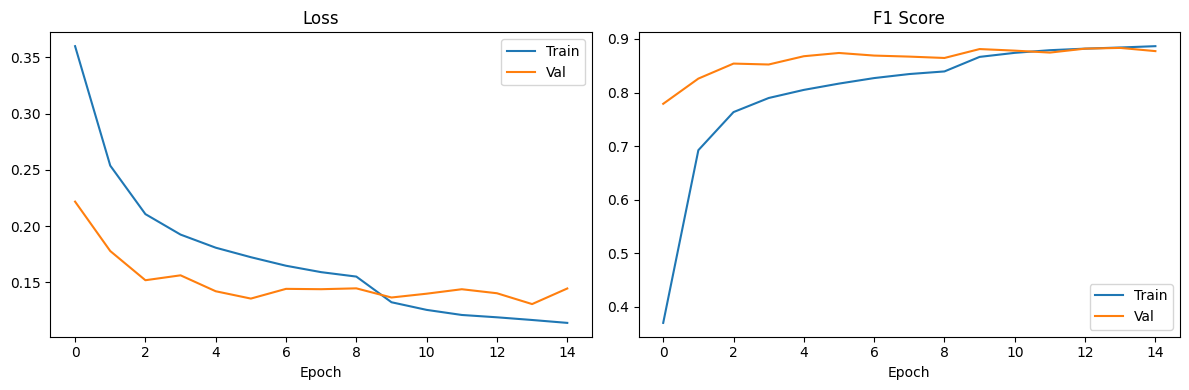

In [100]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_title('Loss')
ax1.legend()
ax1.set_xlabel('Epoch')

ax2.plot(history['train_f1'], label='Train')
ax2.plot(history['val_f1'], label='Val')
ax2.set_title('F1 Score')
ax2.legend()
ax2.set_xlabel('Epoch')

plt.tight_layout()
plt.show()

## 5. Phase 1 Prediction - Task 1 Groups
For each group of 5 items, check all 10 possible pairs. If ANY pair has high duplicate probability → predict positive.

In [101]:
# We need CLIP embeddings for phase1 items too
# Check which phase1 items have embeddings
phase1_ids = set(df_phase1_transformed['itemId'].astype(str).tolist())
train_ids = set(df_train_transformed['itemId'].astype(str).tolist())
emb_ids = set(clip_embeddings_dict.keys())

# Get all item IDs from task_1
task1_item_ids = set()
for col in ['item1', 'item2', 'item3', 'item4', 'item5']:
    task1_item_ids.update(df_task_1[col].astype(str).tolist())

print(f"Task 1 unique items: {len(task1_item_ids)}")
print(f"In embeddings: {len(task1_item_ids & emb_ids)}")
print(f"Missing from embeddings: {len(task1_item_ids - emb_ids)}")
print(f"In phase1: {len(task1_item_ids & phase1_ids)}")
print(f"In train: {len(task1_item_ids & train_ids)}")

Task 1 unique items: 75000
In embeddings: 0
Missing from embeddings: 75000
In phase1: 75000
In train: 0


In [102]:
# Create phase1 item dataset - we need to preprocess phase1 items
# Phase1 items don't have labels but we need the same features
# For items not in embeddings, zero vectors are used as fallback

phase1_item_dataset = LightweightItemDataset(
    df_phase1_transformed, vocab_manager,
    image_embeddings_dict=clip_embeddings_dict,
    text_embeddings_dict=text_embeddings_dict
)
print(f"Phase 1 item dataset: {len(phase1_item_dataset)} items")

# Check how many task1 items are in phase1 dataset
found = sum(1 for tid in task1_item_ids if tid in phase1_item_dataset.id_to_idx)
print(f"Task 1 items found in phase1 dataset: {found}/{len(task1_item_ids)}")


Phase 1 item dataset: 199835 items
Task 1 items found in phase1 dataset: 75000/75000


In [103]:
from itertools import combinations

# Load best model
model.load_state_dict(torch.load("siamese_best.pth", map_location=device, weights_only=True))
model.eval()
print("Best model loaded!")

def score_group(model, group_items, item_dataset, device):
    """Score a group, returning raw logit of the best pair.
    
    We use raw logits (not sigmoid) for ranking because sigmoid saturates
    near 1.0 — logits give much better score separation when ranking 15k groups.
    Returns: (max_logit, sigmoid_score_of_best_pair, best_pair_ids)
    """
    item_features = []
    valid_ids = []
    for item_id in group_items:
        feat = item_dataset.get_item_by_id(str(item_id))
        if feat is not None:
            item_features.append(feat)
            valid_ids.append(item_id)

    if len(item_features) < 2:
        return -999.0, 0.0, (None, None)

    max_logit = -999.0
    best_pair = (None, None)

    for (i, feat1), (j, feat2) in combinations(enumerate(item_features), 2):
        batch1 = {k: v.unsqueeze(0).to(device) if isinstance(v, torch.Tensor) else v
                  for k, v in feat1.items() if k != 'item_id'}
        batch2 = {k: v.unsqueeze(0).to(device) if isinstance(v, torch.Tensor) else v
                  for k, v in feat2.items() if k != 'item_id'}
        with torch.no_grad():
            logit = model(batch1, batch2).item()   # raw logit, not sigmoid
        if logit > max_logit:
            max_logit = logit
            best_pair = (valid_ids[i], valid_ids[j])

    sigmoid_score = 1.0 / (1.0 + 2.718281828 ** (-max_logit))
    return max_logit, sigmoid_score, best_pair

print("Scoring function defined!")


Best model loaded!
Scoring function defined!


In [104]:
# Score all groups using raw logits for better ranking separation
raw_logits = []
raw_scores = []
best_pairs = []

print(f"Scoring {len(df_task_1)} groups...")
for idx, row in tqdm(df_task_1.iterrows(), total=len(df_task_1)):
    group_items = [row['item1'], row['item2'], row['item3'], row['item4'], row['item5']]
    logit, score, pair = score_group(model, group_items, phase1_item_dataset, device)
    raw_logits.append(logit)
    raw_scores.append(score)
    best_pairs.append(pair)

df_task_1['max_logit'] = raw_logits
df_task_1['max_score'] = raw_scores
df_task_1['best_pair'] = best_pairs

# Auto-calibrate on logits (better separation than sigmoid near saturation)
TARGET_POSITIVE_RATE = 0.20
logits_sorted = sorted(raw_logits, reverse=True)
auto_threshold_logit = logits_sorted[int(TARGET_POSITIVE_RATE * len(logits_sorted))]
auto_threshold = 1.0 / (1.0 + 2.718281828 ** (-auto_threshold_logit))
print(f"Auto-calibrated logit threshold: {auto_threshold_logit:.4f}  (sigmoid: {auto_threshold:.4f})")

df_task_1['prediction'] = (df_task_1['max_logit'] >= auto_threshold_logit).astype(int)

print(f"\nPrediction distribution:")
print(df_task_1['prediction'].value_counts())
print(f"Positive rate: {df_task_1['prediction'].mean():.2%}  (target ~20%)")


Scoring 15000 groups...


100%|██████████| 15000/15000 [06:26<00:00, 38.79it/s]

Auto-calibrated logit threshold: 5.9783  (sigmoid: 0.9975)

Prediction distribution:
prediction
0    11999
1     3001
Name: count, dtype: int64
Positive rate: 20.01%  (target ~20%)


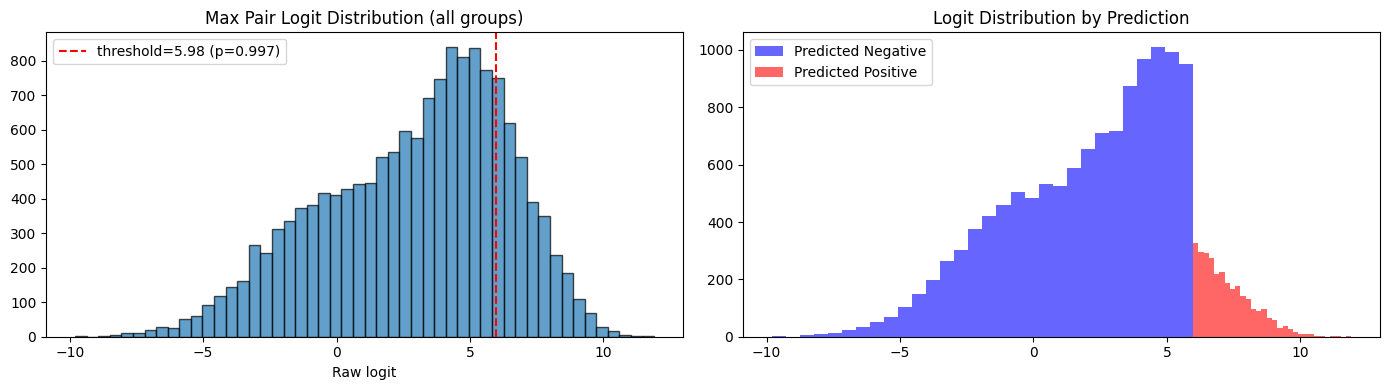

In [105]:
# Score distribution — logits give much better separation than sigmoid near saturation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(raw_logits, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=auto_threshold_logit, color='red', linestyle='--',
                label=f'threshold={auto_threshold_logit:.2f} (p={auto_threshold:.3f})')
axes[0].set_title('Max Pair Logit Distribution (all groups)')
axes[0].set_xlabel('Raw logit')
axes[0].legend()

pos_logits = [s for s, p in zip(raw_logits, df_task_1['prediction']) if p == 1]
neg_logits = [s for s, p in zip(raw_logits, df_task_1['prediction']) if p == 0]
axes[1].hist(neg_logits, bins=30, alpha=0.6, label='Predicted Negative', color='blue')
axes[1].hist(pos_logits, bins=30, alpha=0.6, label='Predicted Positive', color='red')
axes[1].set_title('Logit Distribution by Prediction')
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Demo Output - Show Groups with Predictions

In [106]:
def show_group(group_idx, df_task, df_items, images_folder, show_images=True):
    """Display a group with its items, titles, and prediction."""
    row = df_task.iloc[group_idx]
    item_ids = [row['item1'], row['item2'], row['item3'], row['item4'], row['item5']]
    prediction = row['prediction']
    score = row['max_score']
    best_pair = row['best_pair']
    
    pred_text = "DUPLICATE DETECTED" if prediction == 1 else "NO DUPLICATE"
    pred_color = '\033[91m' if prediction == 1 else '\033[92m'
    reset = '\033[0m'
    
    print(f"\n{'='*80}")
    print(f"Group #{group_idx} | Prediction: {pred_color}{pred_text}{reset} | Max Score: {score:.4f}")
    if prediction == 1:
        print(f"Best matching pair: items {best_pair[0]} & {best_pair[1]}")
    print(f"{'='*80}")
    
    if show_images:
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    for i, item_id in enumerate(item_ids):
        item_row = df_items[df_items['itemId'] == item_id]
        if len(item_row) == 0:
            print(f"  Item {i+1}: ID={item_id} - NOT FOUND")
            if show_images:
                axes[i].set_title(f"ID: {item_id}\nNOT FOUND")
                axes[i].axis('off')
            continue
        
        item_row = item_row.iloc[0]
        title = str(item_row.get('title', 'N/A'))[:60]
        geo = item_row.get('geo', 'N/A')
        price = item_row.get('price', 'N/A')
        
        is_in_pair = prediction == 1 and best_pair is not None and item_id in [best_pair[0], best_pair[1]]
        marker = " ★" if is_in_pair else ""
        
        print(f"  Item {i+1}: ID={item_id} | {geo} | {price} | {title}{marker}")
        
        if show_images:
            img_path = os.path.join(images_folder, f"{item_id}.jpg")
            try:
                img = Image.open(img_path).convert("RGB")
                axes[i].imshow(img)
            except:
                axes[i].text(0.5, 0.5, 'No image', ha='center', va='center', fontsize=12)
            
            border_color = 'red' if is_in_pair else 'gray'
            for spine in axes[i].spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(3 if is_in_pair else 1)
            axes[i].set_title(f"ID: {item_id}\n{geo} | {price}", fontsize=9)
            axes[i].set_xticks([])
            axes[i].set_yticks([])
    
    if show_images:
        plt.suptitle(f"Group #{group_idx} — {pred_text} (score: {score:.4f})", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

print("Demo function defined!")

Demo function defined!


Showing 3 predicted POSITIVE groups:

Group #613 | Prediction: DUPLICATE DETECTED | Max Score: 0.9998
Best matching pair: items 561587 & 1157202
  Item 1: ID=561587 | it | 64.0 | Borsetta Nobo ★
  Item 2: ID=686018 | lv | 64.0 | Soma Nobo
  Item 3: ID=853378 | bg | 119.0 | Дамска чанта Nobo
  Item 4: ID=1100608 | cz | 1540.0 | Kabelka Nobo
  Item 5: ID=1157202 | it | 64.0 | Borsetta Nobo ★


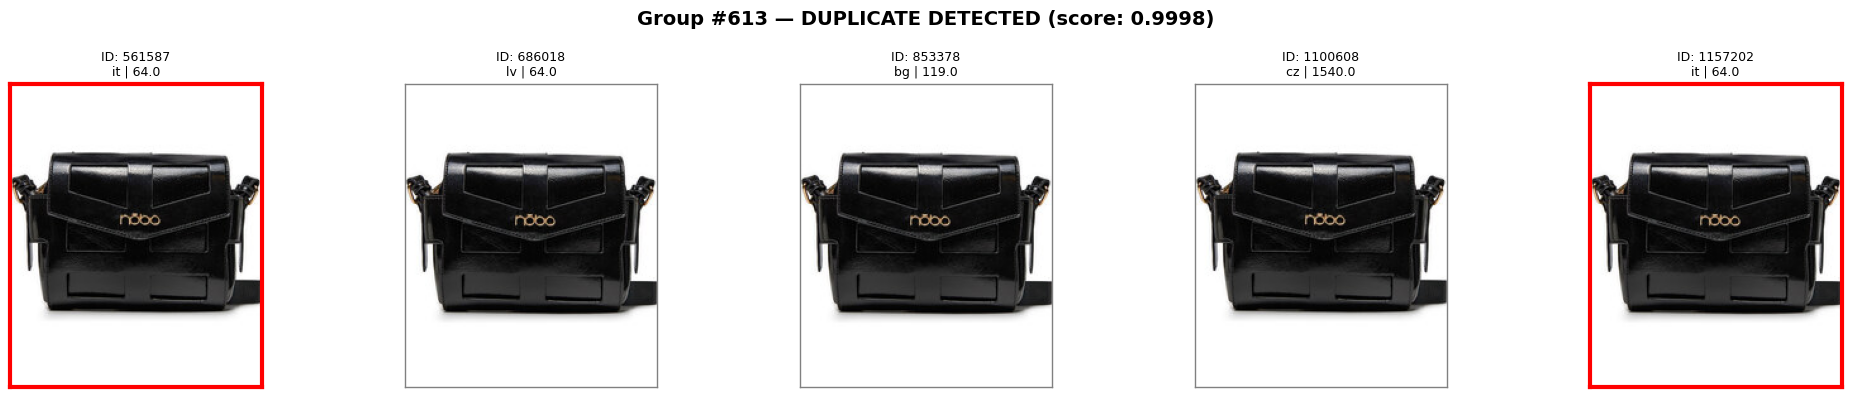


Group #620 | Prediction: DUPLICATE DETECTED | Max Score: 0.9995
Best matching pair: items 104930 & 439608
  Item 1: ID=77482 | lt | 99.95 | Kepurės ir šaliko komplektas Guess
  Item 2: ID=104930 | sk | 59.95 | Sneakersy Skechers ★
  Item 3: ID=439608 | sk | 59.95 | Sneakersy Skechers ★
  Item 4: ID=1034467 | bg | 59.0 | Чанта за кръст Helly Hansen
  Item 5: ID=1065019 | bg | 774.0 | Сникърси Boss Gary Tenn Sdltbb 50517057 Бежов


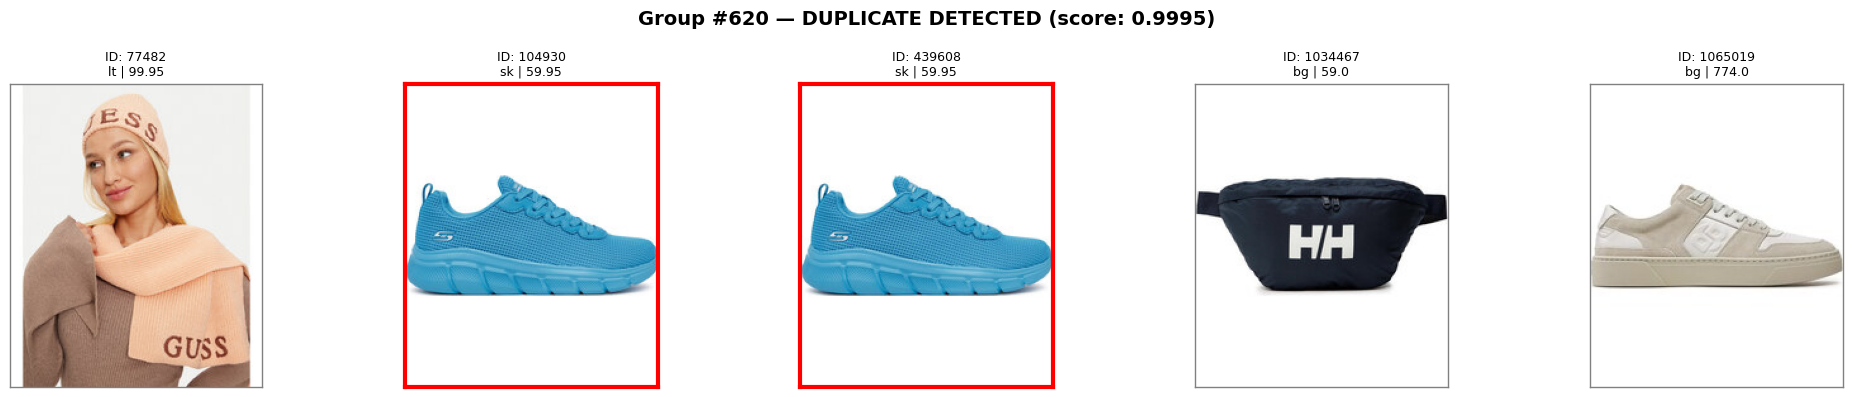


Group #628 | Prediction: DUPLICATE DETECTED | Max Score: 0.9982
Best matching pair: items 59512 & 480691
  Item 1: ID=59512 | hu | 57910.0 | Sportcipők Liu Jo ★
  Item 2: ID=125663 | lv | 24.95 | Cepure ar nagu New Era
  Item 3: ID=147112 | sk | 14.29 | Svetloružové dámske slnečné okuliare VUCH Marella Pink
  Item 4: ID=319780 | hr | 6.99 | Šilterica Nelli Blu
  Item 5: ID=480691 | si | 133.95 | Sandali Guess ★


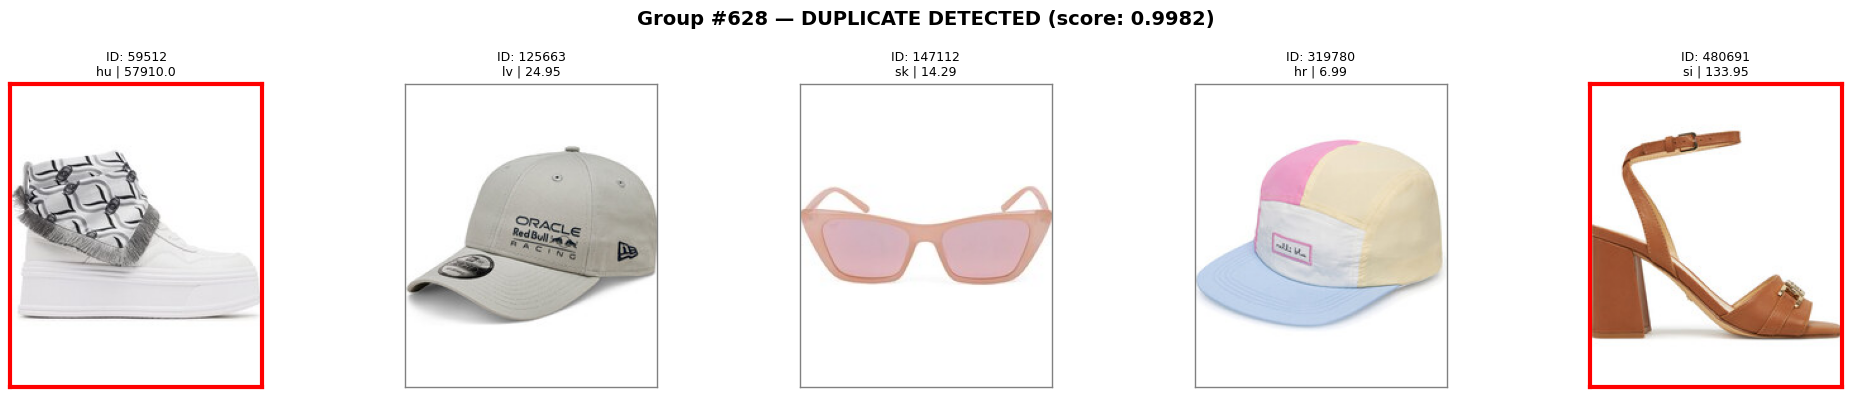

In [112]:
# Show some predicted POSITIVE groups
positive_groups = df_task_1[df_task_1['prediction'] == 1].index.tolist()
negative_groups = df_task_1[df_task_1['prediction'] == 0].index.tolist()

print(f"Showing 3 predicted POSITIVE groups:")
for idx in positive_groups[120:123]:
    show_group(idx, df_task_1, df_phase1, images_folder, show_images=True)

Showing 3 predicted NEGATIVE groups:

Group #0 | Prediction: NO DUPLICATE | Max Score: 0.9863
  Item 1: ID=130622 | hr | 99.9 | Mali ženski novčanik Gianni Chiarini
  Item 2: ID=292253 | hr | 29.9 | Balerinke Sergio Bardi
  Item 3: ID=463442 | hu | 9990.0 | Calvin Klein Jeans gyerek sapka piros, IU0IU00440
  Item 4: ID=483968 | hu | 53880.0 | Bokacsizma Aldo
  Item 5: ID=1253745 | sk | 40.94 | Made Of Emotion Woman's Shorts M593
  Item 1: ID=130622 | hr | 99.9 | Mali ženski novčanik Gianni Chiarini
  Item 2: ID=292253 | hr | 29.9 | Balerinke Sergio Bardi
  Item 3: ID=463442 | hu | 9990.0 | Calvin Klein Jeans gyerek sapka piros, IU0IU00440
  Item 4: ID=483968 | hu | 53880.0 | Bokacsizma Aldo
  Item 5: ID=1253745 | sk | 40.94 | Made Of Emotion Woman's Shorts M593


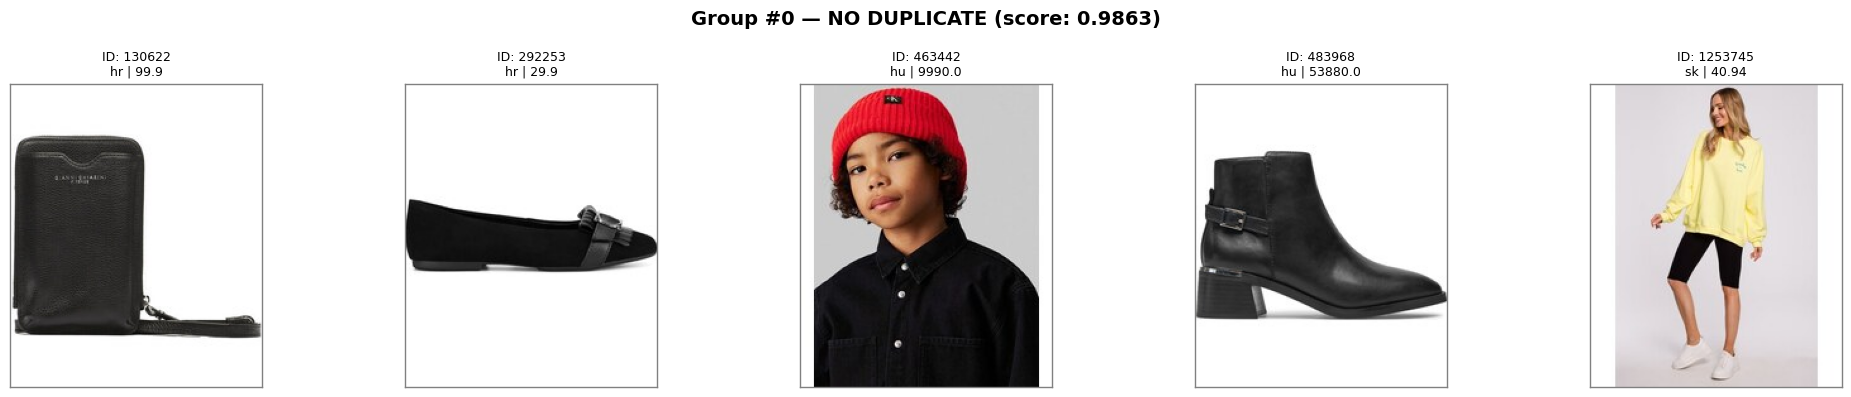


Group #1 | Prediction: NO DUPLICATE | Max Score: 0.4899
  Item 1: ID=82627 | sk | 34.66 | Diesel Pyžamo - UMKIT-JUST-STARK PYJAMA viacfarebné
  Item 2: ID=388496 | hu | 37990.0 | Sportcipők New Balance
  Item 3: ID=553738 | bg | 31.0 | Мъжки колан Vans Deppster II Web VN0A31J1CHH1 Сив
  Item 4: ID=638400 | cz | 370.0 | Nazouváky ONLY Shoes
  Item 5: ID=884327 | sk | 21.5 | Trendyol Navy Blue A-Line Glittery Lined Chiffon Woven Dress
  Item 2: ID=388496 | hu | 37990.0 | Sportcipők New Balance
  Item 3: ID=553738 | bg | 31.0 | Мъжки колан Vans Deppster II Web VN0A31J1CHH1 Сив
  Item 4: ID=638400 | cz | 370.0 | Nazouváky ONLY Shoes
  Item 5: ID=884327 | sk | 21.5 | Trendyol Navy Blue A-Line Glittery Lined Chiffon Woven Dress


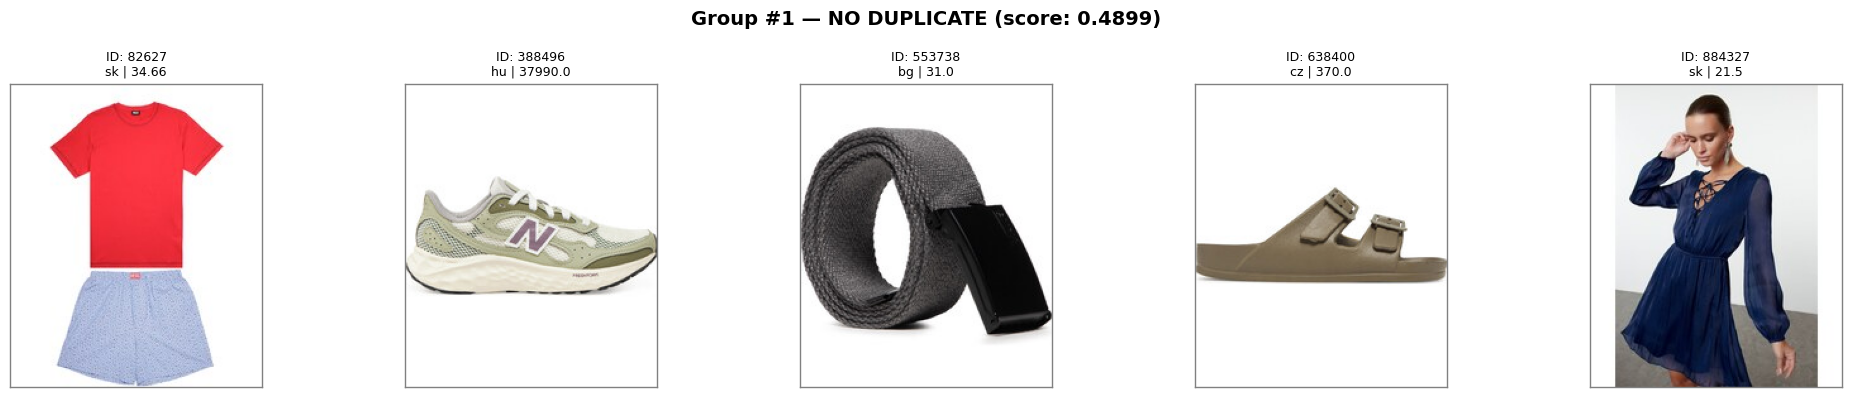


Group #2 | Prediction: NO DUPLICATE | Max Score: 0.0191
  Item 1: ID=46130 | si | 220.0 | Čevlji brez vezalk Coach
  Item 2: ID=333489 | sk | 18.84 | Rip Curl IMPACT REG BEANIE Mauve Winter Hat
  Item 3: ID=644448 | bg | 259.9 | Раница Tommy Hilfiger в бежово голям размер с апликация AM0A
  Item 4: ID=848154 | si | 22.95 | Majica The North Face
  Item 5: ID=1178149 | gr | 54.9 | Σακίδιο Timberland
  Item 2: ID=333489 | sk | 18.84 | Rip Curl IMPACT REG BEANIE Mauve Winter Hat
  Item 3: ID=644448 | bg | 259.9 | Раница Tommy Hilfiger в бежово голям размер с апликация AM0A
  Item 4: ID=848154 | si | 22.95 | Majica The North Face
  Item 5: ID=1178149 | gr | 54.9 | Σακίδιο Timberland


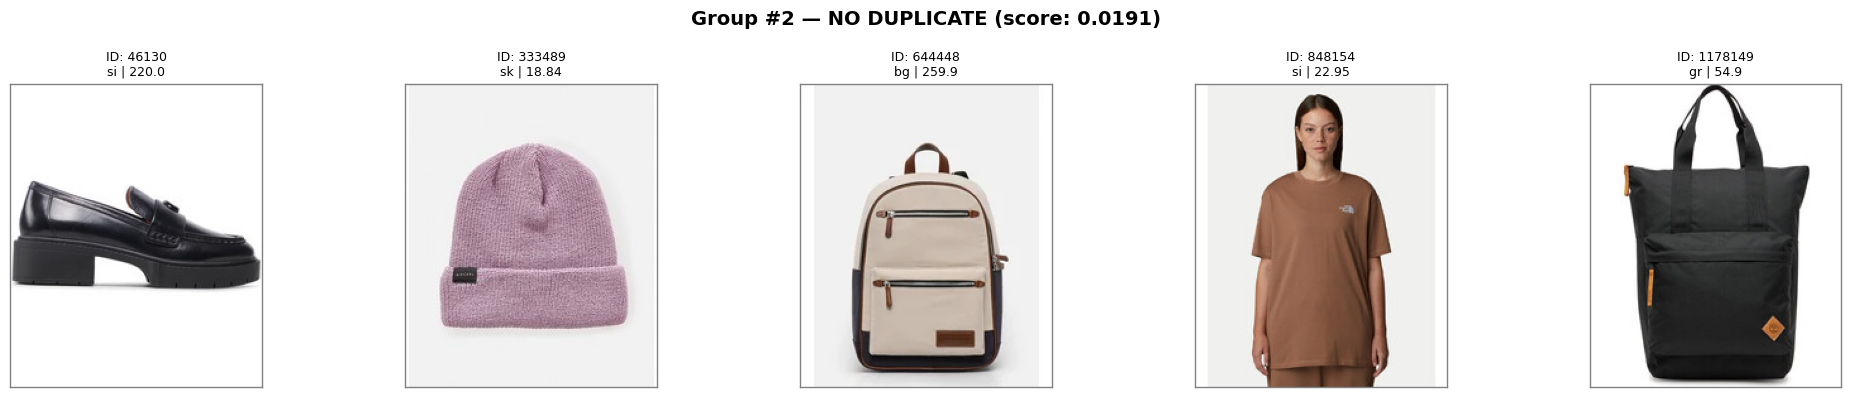

In [108]:
# Show some predicted NEGATIVE groups
print(f"Showing 3 predicted NEGATIVE groups:")
for idx in negative_groups[:3]:
    show_group(idx, df_task_1, df_phase1, images_folder, show_images=True)

Showing 3 borderline groups (scores near threshold=0.9975):

Group #3106 | Prediction: DUPLICATE DETECTED | Max Score: 0.9975
Best matching pair: items 1029689 & 1061847
  Item 1: ID=273032 | hr | 99.99 | Gumene čizme Hunter
  Item 2: ID=779083 | sk | 67.95 | Sneakersy Puma
  Item 3: ID=810546 | lt | 9.99 | Moteriškas Diržas Jenny Fairy
  Item 4: ID=1029689 | sk | 59.99 | Children's sandals Keen Newport H2 JR Multi/Tillandsia Purpl ★
  Item 5: ID=1061847 | sk | 59.99 | Children's sandals Keen Newport H2 JR Multi/Tillandsia Purpl ★


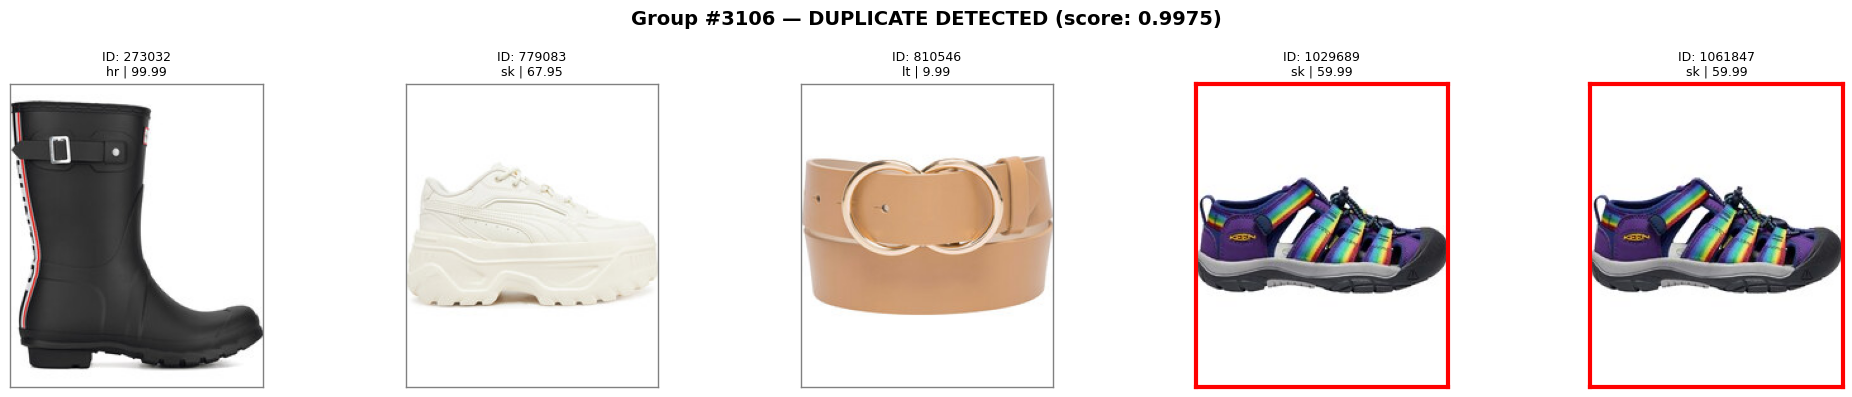


Group #6160 | Prediction: DUPLICATE DETECTED | Max Score: 0.9975
Best matching pair: items 49347 & 933499
  Item 1: ID=17060 | sk | 28.59 | Starter Black Label Men's shorts Retro green
  Item 2: ID=25348 | sk | 28.59 | Starter Black Label Men's shorts Retro green
  Item 3: ID=49347 | bg | 108.0 | Обувки за футбол Puma ★
  Item 4: ID=933499 | it | 41.95 | Scarpe stiletto Nine West ★
  Item 5: ID=1016479 | ro | 788.0 | Geantă KARL LAGERFELD


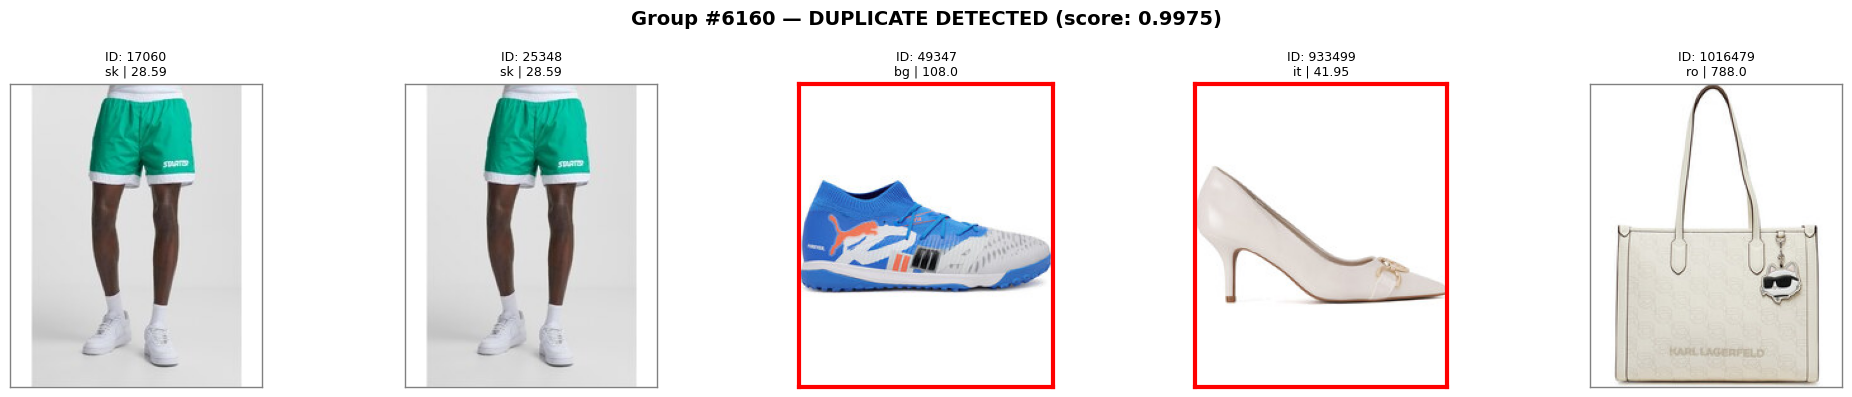


Group #1665 | Prediction: NO DUPLICATE | Max Score: 0.9975
  Item 1: ID=94625 | lv | 105.95 | Snīkeri S.W.C Stepney Workers Club
  Item 2: ID=865694 | lt | 79.99 | Laisvalaikio batai Nike
  Item 3: ID=1025964 | cz | 2999.0 | Kabelka Tommy Hilfiger černá barva, AW0AW15178
  Item 4: ID=1063284 | sk | 59.79 | Doctor Nap Woman's Dressing Gown Swa.1078.
  Item 5: ID=1216317 | hr | 56.9 | Tenisice Skechers


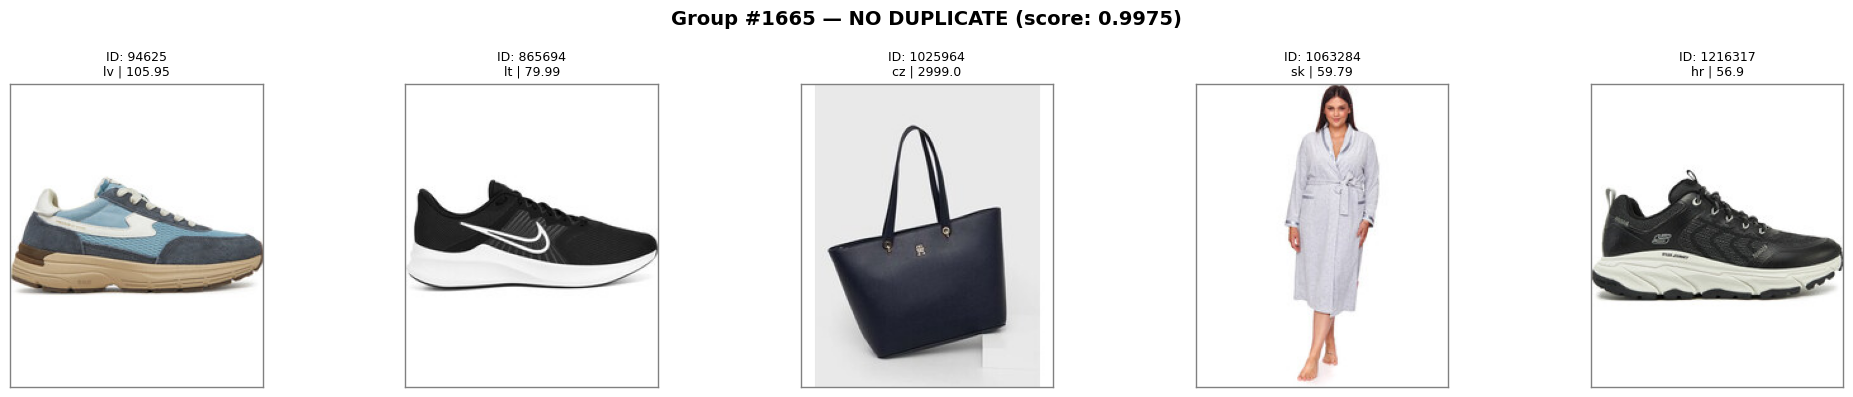

In [109]:
# Show borderline cases (scores close to auto_threshold)
borderline = df_task_1.iloc[(df_task_1['max_score'] - auto_threshold).abs().argsort()[:3]].index.tolist()
print(f"Showing 3 borderline groups (scores near threshold={auto_threshold:.4f}):")
for idx in borderline:
    show_group(idx, df_task_1, df_phase1, images_folder, show_images=True)


## 7. Save Submission

In [111]:
# Save submission — plain text, one integer per line, no header
predictions_out = df_task_1['prediction'].astype(int).tolist()
with open('submission_phase1.txt', 'w') as f:
    f.write('\n'.join(map(str, predictions_out)))

print(f"Saved {len(predictions_out)} predictions to submission_phase1.txt")
print(f"Positive: {sum(predictions_out)} ({sum(predictions_out)/len(predictions_out):.2%})")


Saved 15000 predictions to submission_phase1.txt
Positive: 3001 (20.01%)
